Best K-Value: 16 Best Accuracy: 96.44444444444444


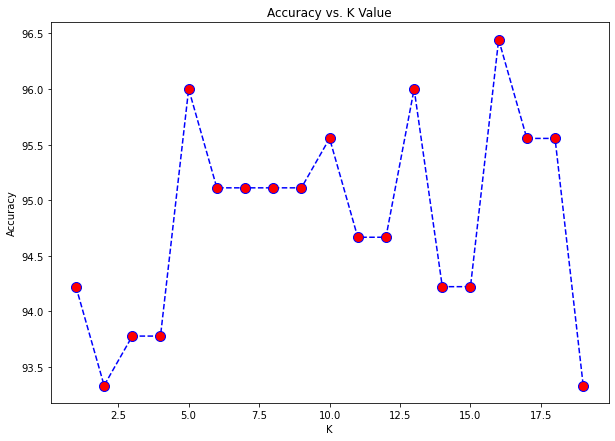

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

url = 'https://raw.githubusercontent.com/ruiwu1990/CSCI_4120/master/KNN/iris.data'
df = pd.read_csv(url, header = None)
df.head()

for x in range(df.shape[0]):
    if df.iat[x, 4] == 'Iris-setosa':
        df.iat[x, 4] = 0
    elif df.iat[x, 4] == 'Iris-versicolor':
        df.iat[x, 4] = 1
    elif df.iat[x, 4] == 'Iris-virginica':
        df.iat[x, 4] = 2
        
df.head()      

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df.drop(columns=df.columns[-1:]))
sc_transform = scaler.transform(df.drop(columns=df.columns[-1:]))
sc_df = pd.DataFrame(sc_transform)
sc_df.head()

from sklearn.model_selection import train_test_split

X = sc_transform
y = df.iloc[:,-1]

from sklearn.neighbors import KNeighborsClassifier
accuracy = []

for a in range(1, 20):
    n_accuracy = []
    for b in range(0, 5):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

        X_train = X_train.astype('float')
        X_test = X_test.astype('float')
        y_train = y_train.astype('int')
        y_test = y_test.astype('int')
    
        test_result = []
        
        k = a
        knn = KNeighborsClassifier(n_neighbors = k)
        knn.fit(X_train, y_train)
        prediction = knn.predict(X_test)
        test_result = np.equal(prediction, y_test)
        correct = 0
    
        for c in test_result:
            if c:
                correct += 1
            #end if
        #end for
        correct = correct/len(test_result)*100
        n_accuracy.append(correct)
    
    accuracy.append(np.mean(n_accuracy))
#print(accuracy)
    

plt.figure(figsize=(10, 7))
plt.plot(range(1, 20), accuracy, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Accuracy vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')

max_value = max(accuracy)
max_index = accuracy.index(max_value)

print('Best K-Value:', max_index + 1, 'Best Accuracy:', max_value)

    


    